# Conceptos basicos de regresion
- Existe una ecuacion detras _y = x0 + c1x1 +c2x2 + c3x3_ (Es una linea recta)
- El objetivo es averiguar ;ps cpefivientes optimos, que reduzcan la distancia entre las predicciones y los valores reales
- Puede ser una regresion simple o multivariable
- Esa distancia se llama _R2_ (coeficiente de determinacion)

## Descripcion de los campos
- price (#)
- area (#)
- bedrooms (#)
- bathrooms (#)
- stories (#)
- mainroad (yes/no)
- guestroom (yes/no)
- basement (yes/no)
- hotwaterheating (yes/no)
- airconditioning (yes/no)
- parking (#)
- prefarea (yes/no)
- furnishigstatus

(En este caso la idea seria predecir el precio de las casas, basado en los 545 registros del dataset)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('../../../../Archivos-Analisis/files-practica-m43/ANalista de Datos M43 - Housing.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


# EDA

In [5]:
df.sample(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
16,9100000,6600,4,2,2,yes,yes,yes,no,yes,1,yes,unfurnished
237,4620000,5010,3,1,2,yes,no,yes,no,no,0,no,semi-furnished
197,4956000,2800,3,2,2,no,no,yes,no,yes,1,no,semi-furnished
281,4270000,4500,2,1,1,yes,no,no,no,yes,2,no,furnished
223,4760000,6321,3,1,2,yes,no,yes,no,yes,1,no,furnished


In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [9]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
price,545.0,4766729.25,1870439.62,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5150.54,2170.14,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.97,0.74,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.29,0.50,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.81,0.87,1.0,1.0,2.0,2.0,4.0
parking,545.0,0.69,0.86,0.0,0.0,0.0,1.0,3.0


In [12]:
# Observamos el valor unico de cada columna
df.nunique().sort_values()

mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
prefarea              2
furnishingstatus      3
bathrooms             4
stories               4
parking               4
bedrooms              6
price               219
area                284
dtype: int64

Insights
- Se deben de cambiar las columnas que tienen valores en cadena a numero (1, 0)
- Se debe cambiar furnishingstatus a 1 / 2/ 3
- Es un dataset completo

---

# Feature Engineering

In [13]:
# Cambiamos los valores de las columnas
df['mainroad'] = df['mainroad'].replace({'yes': 1, 'no': 0}, regex=True)
df['guestroom'] = df['guestroom'].replace({'yes': 1, 'no': 0}, regex=True)
df['basement'] = df['basement'].replace({'yes': 1, 'no': 0}, regex=True)
df['hotwaterheating'] = df['hotwaterheating'].replace({'yes': 1, 'no': 0}, regex=True)
df['airconditioning'] = df['airconditioning'].replace({'yes': 1, 'no': 0}, regex=True)
df['prefarea'] = df['prefarea'].replace({'yes': 1, 'no': 0}, regex=True)
df['furnishingstatus'] = df['furnishingstatus'].replace({'unfurnished': 3, 'semi-furnished': 2, 'furnished': 1}, regex=True)

C:\Users\RyanHz\AppData\Local\Temp\ipykernel_20236\2350918610.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['mainroad'] = df['mainroad'].replace({'yes': 1, 'no': 0}, regex=True)
C:\Users\RyanHz\AppData\Local\Temp\ipykernel_20236\2350918610.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['guestroom'] = df['guestroom'].replace({'yes': 1, 'no': 0}, regex=True)
C:\Users\RyanHz\AppData\Local\Temp\ipykernel_20236\2350918610.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a futu

In [ ]:
# Con lo anterior se genera un dataset 100% numerico, con lo que esto el modelo puede trabajar a la perfeccion
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,2
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,2
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,2
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,3
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,1
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,3


# Analisis Correlacion / Bivariado

<Axes: >

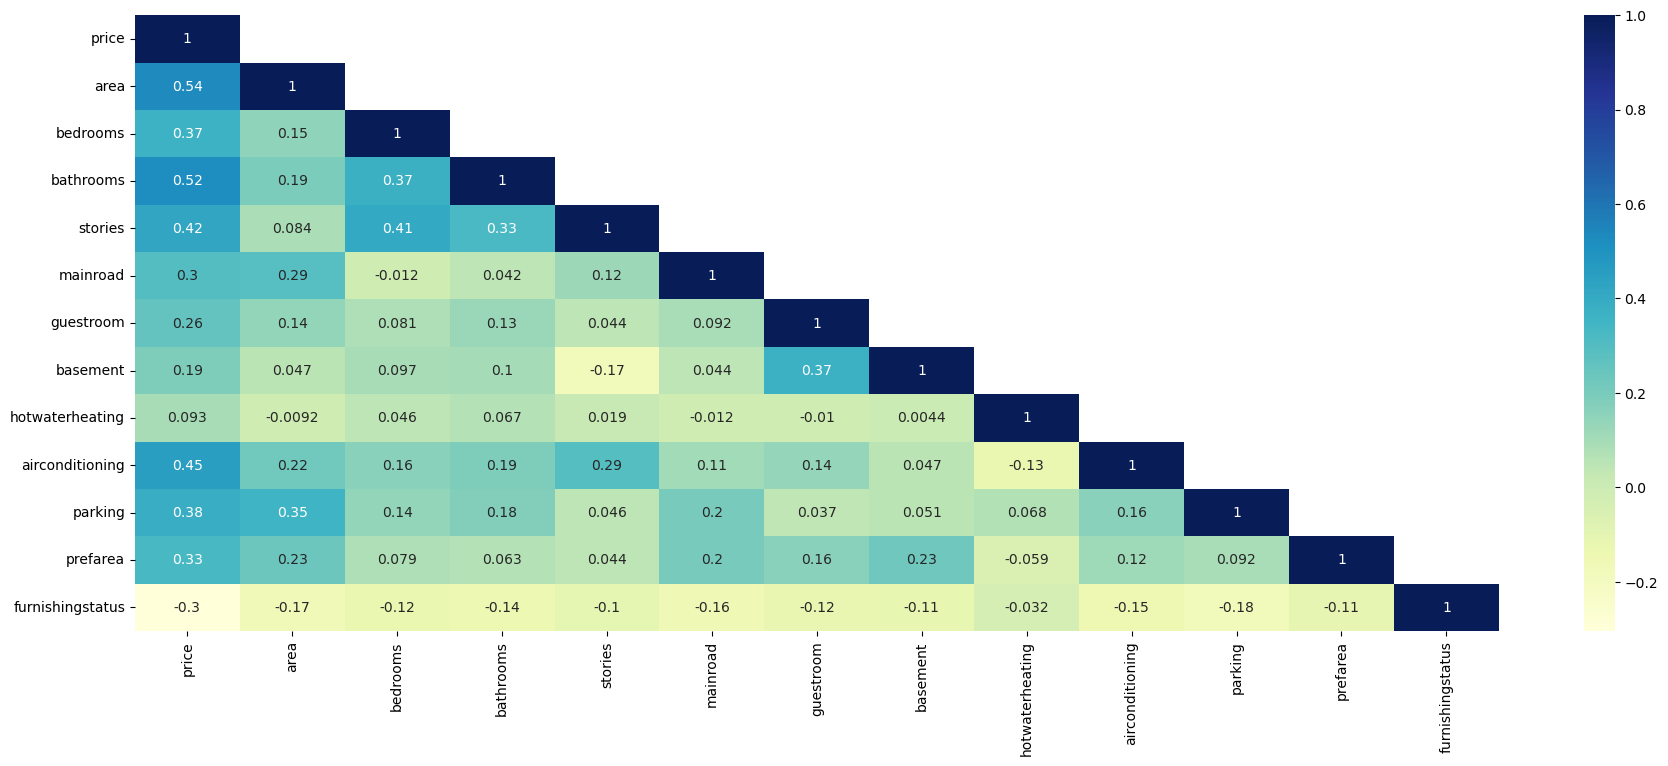

In [15]:
plt.figure(figsize=(22,8))
corr_df = corr = df.corr(method='pearson')
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
sns.heatmap(df_lt, annot=True, cmap='YlGnBu')

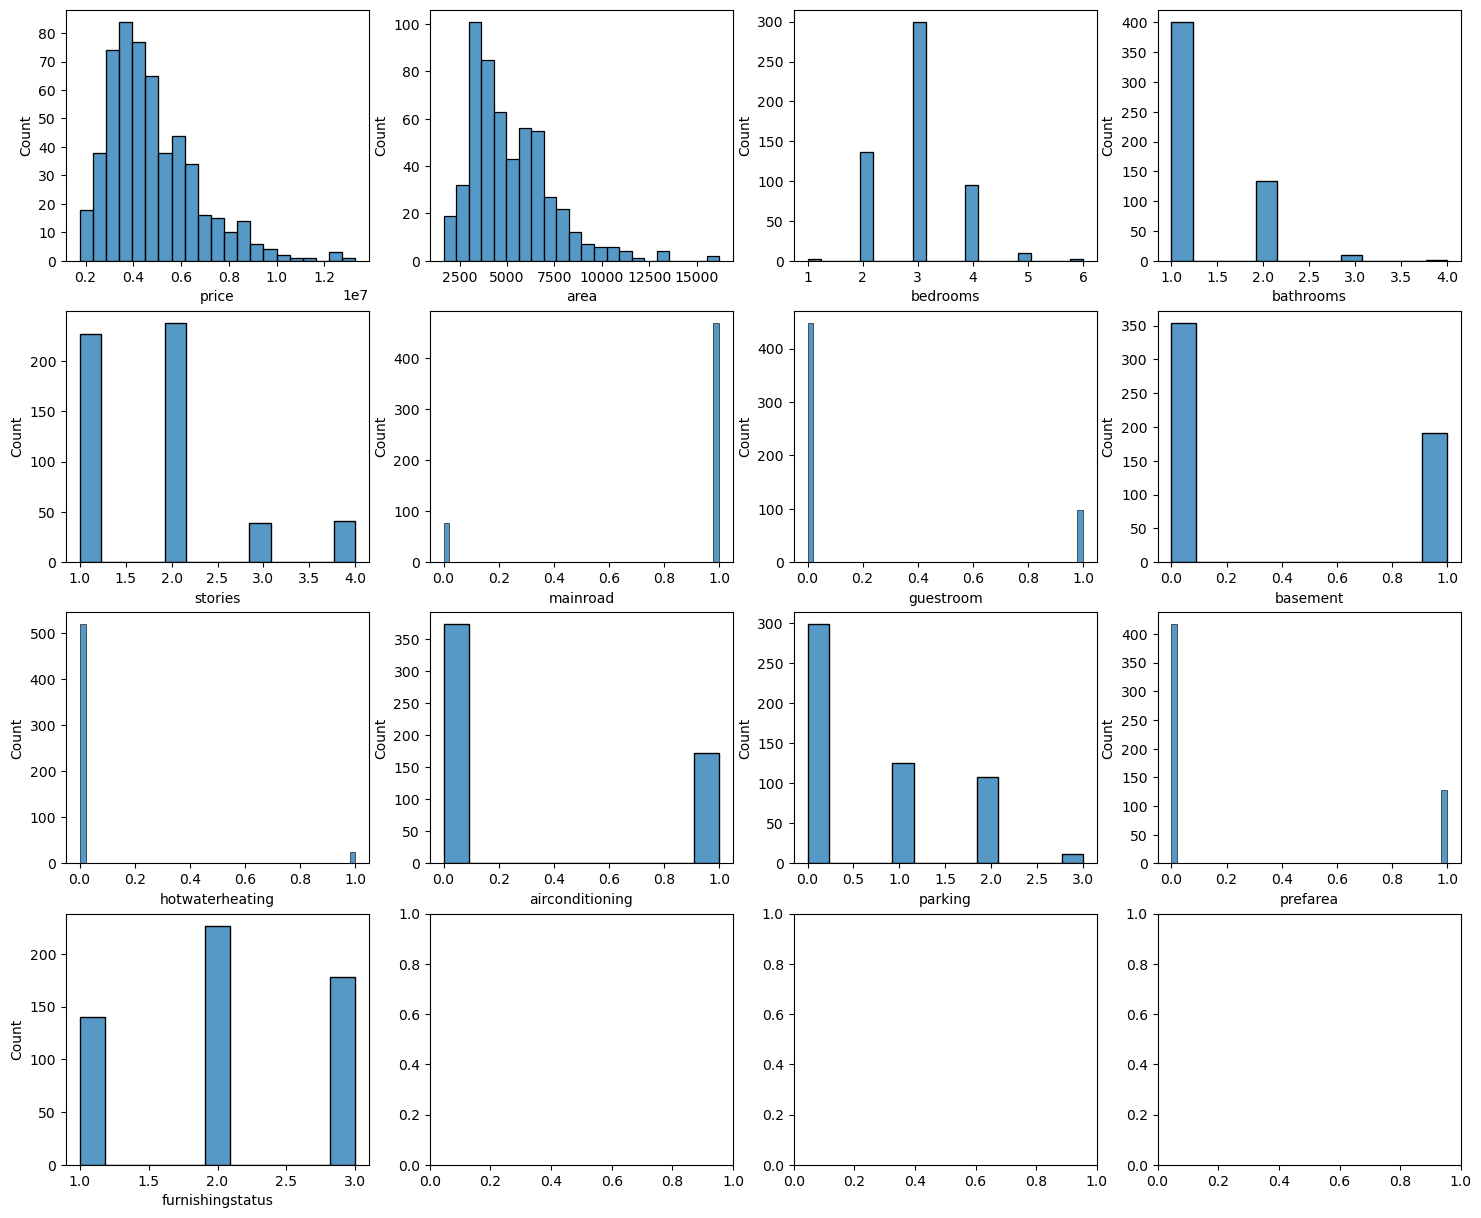

In [17]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18,15))
for i, colums in enumerate(df.select_dtypes(include=['int64', 'float64']).columns):
    sns.histplot(df[colums], kde=False, ax=axes[i//4, i%4])

Insights
- La columna de area tiene dimensiones muy grandes comparando al resto de las variables, podria requerirse su modificacion de orden de magnitud

## Analisis Bivariado

In [18]:
df.groupby(['furnishingstatus']).mean().round(2).T

furnishingstatus,1,2,3
price,5495696.00,4907524.23,4013831.46
area,5688.10,5166.34,4707.60
bedrooms,3.06,3.01,2.83
bathrooms,1.38,1.30,1.19
stories,1.94,1.80,1.70
mainroad,0.94,0.86,0.79
guestroom,0.24,0.18,0.12
basement,0.41,0.38,0.27
hotwaterheating,0.04,0.06,0.03
airconditioning,0.44,0.29,0.25


In [20]:
df.groupby(['bedrooms']).mean().round(2).T

bedrooms,1,2,3,4,5,6
price,2712500.0,3632022.06,4954598.13,5729757.89,5819800.0,4791500.0
area,3710.0,4636.24,5226.62,5582.06,6291.5,3950.0
bathrooms,1.0,1.06,1.27,1.62,1.8,1.5
stories,1.0,1.17,1.93,2.31,2.0,2.0
mainroad,0.5,0.85,0.87,0.86,0.6,1.0
guestroom,0.0,0.12,0.19,0.22,0.2,0.0
basement,0.0,0.25,0.39,0.36,0.6,0.0
hotwaterheating,0.0,0.04,0.05,0.04,0.2,0.0
airconditioning,0.0,0.16,0.36,0.42,0.3,0.0
parking,0.0,0.49,0.72,0.92,0.6,0.5


In [21]:
df.groupby(['bathrooms']).mean().round(2).T

bathrooms,1,2,3,4
price,4206912.72,6209206.32,7282100.0,12250000.0
area,4920.89,5699.53,6677.0,8960.0
bedrooms,2.80,3.38,3.8,4.0
stories,1.63,2.29,2.1,4.0
mainroad,0.85,0.89,0.8,1.0
guestroom,0.15,0.26,0.3,0.0
basement,0.32,0.44,0.5,0.0
hotwaterheating,0.04,0.07,0.1,0.0
airconditioning,0.26,0.50,0.2,1.0
parking,0.61,0.89,1.1,3.0


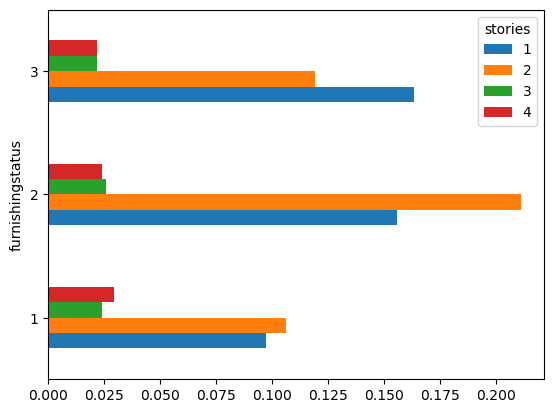

In [22]:
ct = pd.crosstab(df['furnishingstatus'], df['stories'], normalize=True).plot.barh(stacked=False)

# Modelo de Regresion

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [24]:
# Varible independiente
x = df.drop(['price'], axis=1)
# Variable dependiente
y = df[['price']]

In [25]:
y.head(5)

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000


In [26]:
# Dividimos el DF en train y test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.30, random_state=1)

In [27]:
# Regresor
regression_model = LinearRegression()

# Genera el fit de la regresion con la funcion fit
regression_model.fit(x_train, y_train)

LinearRegression()

In [28]:
# Obtenemos el coeficiente
regression_model.score(x_train, y_train)

0.6799674103626108

In [29]:
# Coeficiente de regresion de test
# Es el R2
regression_model.score(x_test, y_test)

0.6621173401969211

In [38]:
# Comparacion de Prediccion vs Actual
y_pred = regression_model.predict(x_test)
df_pref = pd.DataFrame({'Actual': y_test.squeeze(), 'Predicted': y_pred.squeeze().round()})
# print(df_pref)
df_pref

,Actual,Predicted
62,7070000,6291567.0
247,4550000,6390833.0
142,5600000,6529769.0
107,6125000,5564502.0
483,2940000,4230599.0
...,...,...
450,3150000,4008865.0
542,1750000,2717347.0
408,3430000,2810960.0
80,6629000,5677214.0


In [39]:
# Otras Medidas de modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Suma absoluta de las diferencias
mae = mean_absolute_error(y_test, y_pred)
# Suma absoluta de las diferencias al cuadrado
mse = mean_squared_error(y_test, y_pred)
# Raiz de la suma absoluta de las diferencias al cuadrado
rmse = np.sqrt(mse)

In [41]:
print(f'Mean absolute error: {mae:.2f}')
print(f'Mean squared error: {mse:.2f}')
print(f'Root Mean squared error: {rmse:.2f}')

Mean absolute error: 855894.77
Mean squared error: 1375329793553.13
Root Mean squared error: 1172744.56


In [42]:
# Obtiene el coeficiente de la ecuacion
for index, col in enumerate(x_train.columns):
    print(f'Coeficiente de {col}: {regression_model.coef_[0][index]:.2f}')

Coeficiente de area: 246.35
Coeficiente de bedrooms: 47198.86
Coeficiente de bathrooms: 1020173.24
Coeficiente de stories: 525778.96
Coeficiente de mainroad: 476712.98
Coeficiente de guestroom: 275668.95
Coeficiente de basement: 557956.27
Coeficiente de hotwaterheating: 822714.56
Coeficiente de airconditioning: 608777.01
Coeficiente de parking: 274736.45
Coeficiente de prefarea: 500668.03
Coeficiente de furnishingstatus: -202462.67


In [51]:
# Obtenemos los coeficientes en un DataFrame
coeff_data = pd.DataFrame()

coeff_data = pd.concat([coeff_data, pd.DataFrame([{'Coeff': round(regression_model.intercept_[0], 2), 'Var': 'Intercept'}])], ignore_index=True)

# Coefivionete
for idx, col_name in enumerate(x_train.columns):
    coeff_data = pd.concat([coeff_data, pd.DataFrame([{'Coeff': round(regression_model.coef_[0][idx], 2), 'Var': col_name}])], ignore_index=True)
coeff_data

,Coeff,Var
0,315893.90,Intercept
1,246.35,area
2,47198.86,bedrooms
3,1020173.24,bathrooms
4,525778.96,stories
5,476712.98,mainroad
6,275668.95,guestroom
7,557956.27,basement
8,822714.56,hotwaterheating
9,608777.01,airconditioning


Text(0.5, 1.0, 'Comparacion de Valores Reales vs Predichos')

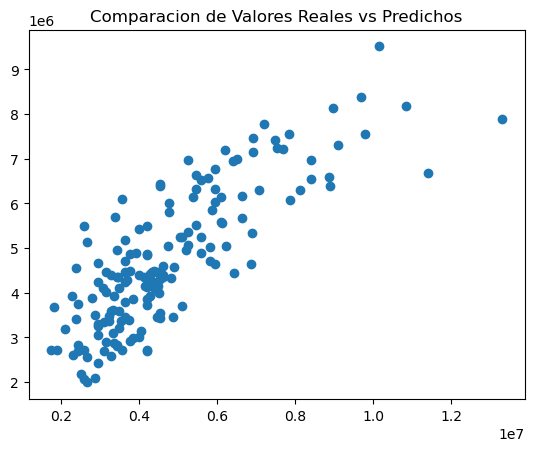

In [52]:
# Comparacion de la prediccion vs los valores reales
predic = regression_model.predict(x_test)
plt.scatter(y_test, predic)
plt.title('Comparacion de Valores Reales vs Predichos')

Text(0.5, 1.0, 'Histograma de Residuos')

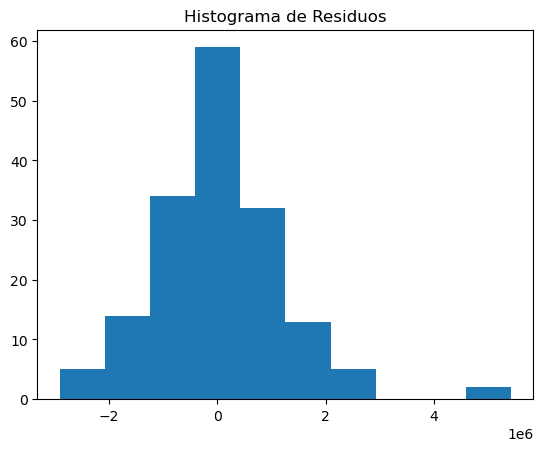

In [53]:
# Residuos
plt.hist(y_test - predic)
plt.title('Histograma de Residuos')